<h1>Задание</h1>

Выбрать модель (или несколько моделей) для обучения. Можно брать предобученные на ImageNet, но нельзя использовать модели, предобученные на задачу распознавания лиц.
Обучить эту модель (модели) на CE loss. Добиться accuracy > 0.7.
Реализовать ArcFace loss.
Обучить модель (модели) на ArcFace loss. Добиться accuracy > 0.7.
Написать небольшой отчет по обучению, сравнить CE loss и ArcFace loss.

<h1>Импорт библиотек</h1>

In [16]:
import pandas as pd
from collections import defaultdict
import random
import cv2
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from torchvision import datasets
import torchvision.transforms as transforms
from PIL import Image


os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from utils import align_face

<h1>Подготовка данных</h1>

Для начала сделаем словарик вида identity: image_filenames, при этом чтобы у каждого человека было 10+ фоток

In [2]:
identities_dict =  defaultdict(list)

with open('../data/celeba/Anno/identity_CelebA.txt', 'r') as file:
    for line in file:
        image_name, id = line.strip().split()
        identities_dict[int(id)].append(image_name)

identities_dict = {id: images for id, images in identities_dict.items() if len(images) >= 10}

In [3]:
len(identities_dict)

8369

Теперь разобъем на train/val и на query/distractors

In [4]:
random.seed(42)
all_identities = list(identities_dict.keys())
random.shuffle(all_identities)

train_val_id = all_identities[:3000]
query_id = all_identities[3000:3100]
distractor_id = all_identities[3100:3600]

Нужно пройтись по датасету, выровнять фото и сохранить их по папкам

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [6]:
os.makedirs('../data/celeba/alligned_img/', exist_ok=True)
shg_model = torch.jit.load("../notebooks/models/shg/shg_final.pt").to(device)
bboxes = pd.read_csv('../data/celeba/Anno/list_bbox_celeba.txt', sep=r'\s+', index_col=0)

In [7]:
def prepare_and_save(image_name, bboxes, model, save_path):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    image = Image.open(f'../data/celeba/img_celeba/{image_name}').convert('RGB')
    bbox = bboxes.loc[image_name]
    x1, y1, w, h = bbox['x_1'], bbox['y_1'], bbox['width'], bbox['height']
    x2, y2 = x1 + w, y1 + h
    image = image.crop((x1 - 0.2 * w, y1 - 0.2 * h, x2 + 0.2 * w, y2 + 0.2 * h))
    image = transform(image)
    image = align_face(image, model)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, image)

In [8]:
def save_class(image_list, path):
    for image_name in image_list:
        save_path = os.path.join(path, image_name)
        prepare_and_save(image_name, bboxes, shg_model, save_path)

In [ ]:
# for id in train_val_id:
#     images = identities_dict[id]
#     train, val = train_test_split(images, test_size=0.2, random_state=42)
#     train_path = f'../data/celeba/alligned_img/train/{id}'
#     val_path =f'../data/celeba/alligned_img/val/{id}'
#     os.makedirs(train_path, exist_ok=True)
#     os.makedirs(val_path, exist_ok=True)

#     save_class(train, train_path)
#     save_class(val, val_path)
        

In [ ]:
# for id in query_id:
#     images = identities_dict[id]
#     query_path = f'../data/celeba/alligned_img/query/{id}'
#     os.makedirs(query_path, exist_ok=True)
#     save_class(images, query_path)

# for id in distractor_id:
#     images = identities_dict[id]
#     distractor_path = f'../data/celeba/alligned_img/distractor/{id}'
#     os.makedirs(distractor_path, exist_ok=True)
#     save_class(images, distractor_path)

In [17]:
transform=transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

train_data = datasets.ImageFolder('../data/celeba/alligned_img/train', transform)
val_data = datasets.ImageFolder('../data/celeba/alligned_img/val', transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

In [18]:
x, y = next(iter(train_loader))

In [21]:
x[0] = x[0]*0.5+0.5

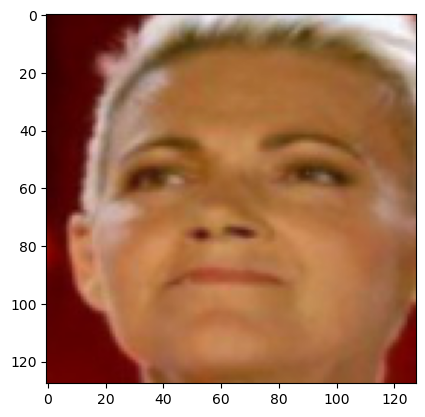

In [22]:
plt.imshow(x[0].permute(1,2,0))

In [28]:
print(train_data.class_to_idx)

{'100': 0, '10000': 1, '10006': 2, '10007': 3, '10008': 4, '10010': 5, '10013': 6, '10026': 7, '10027': 8, '1003': 9, '10031': 10, '10035': 11, '10036': 12, '10042': 13, '10044': 14, '10049': 15, '1005': 16, '10052': 17, '10055': 18, '10059': 19, '10060': 20, '10067': 21, '1007': 22, '10072': 23, '10073': 24, '1008': 25, '10080': 26, '10081': 27, '10083': 28, '10086': 29, '1009': 30, '10090': 31, '10094': 32, '10096': 33, '10098': 34, '101': 35, '10100': 36, '10101': 37, '10106': 38, '1011': 39, '10110': 40, '10112': 41, '10125': 42, '10127': 43, '10128': 44, '10129': 45, '10132': 46, '10135': 47, '10139': 48, '1014': 49, '10141': 50, '10147': 51, '10151': 52, '10156': 53, '10160': 54, '10162': 55, '10168': 56, '1017': 57, '10172': 58, '10173': 59, '10175': 60, '10176': 61, '10177': 62, '1018': 63, '1022': 64, '1028': 65, '1030': 66, '1034': 67, '1037': 68, '1040': 69, '1043': 70, '1046': 71, '105': 72, '1052': 73, '1053': 74, '1055': 75, '106': 76, '1062': 77, '1064': 78, '1066': 79, 